Loading model...


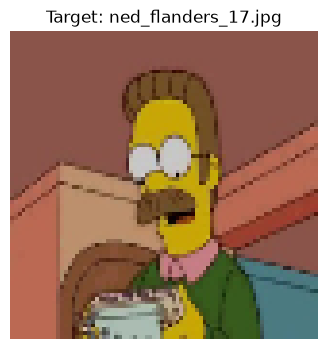


File Name:  ned_flanders_17.jpg
Prediction: Ned Flanders
Confidence: 100.00%



In [2]:
import os
import random
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# --- CONFIGURATION ---
IMG_SIZE = (80, 80)
MODEL_PATH = "simpsons_model.keras"
TEST_DIRECTORY = r"C:\Users\Xian\.cache\kagglehub\datasets\alexattia\the-simpsons-characters-dataset\versions\4\kaggle_simpson_testset\kaggle_simpson_testset"

CHARACTERS = [
    'homer_simpson', 'ned_flanders', 'moe_szyslak', 'lisa_simpson', 'bart_simpson',
    'marge_simpson', 'krusty_the_clown', 'principal_skinner', 'charles_montgomery_burns', 'milhouse_van_houten'
]

def run_prediction():
    # 1. Load the saved model from disk
    if not os.path.exists(MODEL_PATH):
        print(f"Error: '{MODEL_PATH}' not found! Make sure you saved your model in the notebook first.")
        return
        
    print("Loading model...")
    model = tf.keras.models.load_model(MODEL_PATH)
    
    # 2. Gather only images matching our 10 trained characters (skips Lenny, Barney, etc.)
    all_images = [
        f for f in os.listdir(TEST_DIRECTORY) 
        if f.lower().endswith(('.png', '.jpg', '.jpeg')) 
        and any(char in f.lower() for char in CHARACTERS)
    ]
    
    if not all_images:
        print("No matching test images found in the directory!")
        return
        
    # 3. Pick a random test image and read it
    random_image_name = random.choice(all_images)
    img_path = os.path.join(TEST_DIRECTORY, random_image_name)
    raw_img = cv.imread(img_path)
    
    # 4. Preprocess to match training specs (BGR to RGB and Resize)
    processed_img = cv.cvtColor(raw_img, cv.COLOR_BGR2RGB)
    processed_img = cv.resize(processed_img, IMG_SIZE)
    
    # 5. Display the image window
    plt.figure(figsize=(4, 4))
    plt.imshow(processed_img) 
    plt.axis('off')
    plt.title(f"Target: {random_image_name}")
    plt.show()
    
    # 6. Run prediction matrix
    batch_img = np.array([processed_img], dtype=np.float32)
    predictions = model.predict(batch_img, verbose=0)
    
    highest_prob_index = np.argmax(predictions[0])
    confidence = predictions[0][highest_prob_index] * 100
    predicted_char = CHARACTERS[highest_prob_index]
    
    # 7. Print clean terminal outputs
    print("\n" + "="*40)
    print(f"File Name:  {random_image_name}")
    print(f"Prediction: {predicted_char.replace('_', ' ').title()}")
    print(f"Confidence: {confidence:.2f}%")
    print("="*40 + "\n")



Loading model...


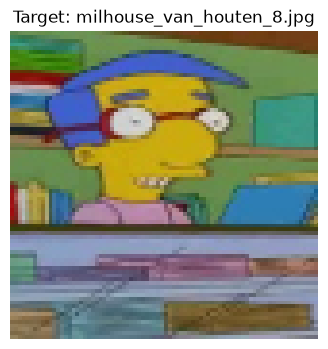


File Name:  milhouse_van_houten_8.jpg
Prediction: Milhouse Van Houten
Confidence: 100.00%



In [17]:
if __name__ == "__main__":
    run_prediction()